In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.linear_model import Perceptron

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [9]:
df = pd.read_csv("/content/mnist_train.csv.zip")
df_test = pd.read_csv("/content/mnist_test.csv.zip")

In [10]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,1x11,1x12,1x13,1x14,1x15,1x16,1x17,1x18,1x19,1x20,1x21,1x22,1x23,1x24,1x25,1x26,1x27,1x28,2x1,2x2,2x3,2x4,2x5,2x6,2x7,2x8,2x9,2x10,2x11,...,27x17,27x18,27x19,27x20,27x21,27x22,27x23,27x24,27x25,27x26,27x27,27x28,28x1,28x2,28x3,28x4,28x5,28x6,28x7,28x8,28x9,28x10,28x11,28x12,28x13,28x14,28x15,28x16,28x17,28x18,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,147,252,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [14]:
X_train = df.drop('label',axis=1).values
y_train = df['label']
X_test = df_test.drop('label',axis=1).values
y_test = df_test['label']

In [15]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

In [18]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [21]:
y_test_cat = to_categorical(y_test,10)
y_train_cat = to_categorical(y_train,10)

In [22]:
Perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')
])

In [24]:
Perceptron.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

In [25]:
history = Perceptron.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8163 - loss: 0.7753 - val_accuracy: 0.8819 - val_loss: 0.4790
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8813 - loss: 0.4542 - val_accuracy: 0.8952 - val_loss: 0.3993
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8922 - loss: 0.4018 - val_accuracy: 0.9009 - val_loss: 0.3674
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8971 - loss: 0.3756 - val_accuracy: 0.9062 - val_loss: 0.3478
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9010 - loss: 0.3590 - val_accuracy: 0.9090 - val_loss: 0.3361


In [26]:
# acc_percep = history.history['accuracy']
# val_acc_percep = history.history['val_accuracy']
# loss_percep = history.history['loss']
# val_loss_percep = history.history['val_loss']

acc_percep = Perceptron.evaluate(X_train_img,y_train_cat)[1]
val_acc_percep = Perceptron.evaluate(X_test_img,y_test_cat)[1]

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9031 - loss: 0.3514
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9090 - loss: 0.3361


In [29]:
#ANN

ANN = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [30]:
ANN.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [31]:
history_ann = ANN.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9290 - loss: 0.2449 - val_accuracy: 0.9637 - val_loss: 0.1187
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9682 - loss: 0.1044 - val_accuracy: 0.9713 - val_loss: 0.0923
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9777 - loss: 0.0725 - val_accuracy: 0.9702 - val_loss: 0.1001
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9827 - loss: 0.0545 - val_accuracy: 0.9741 - val_loss: 0.0879
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9868 - loss: 0.0437 - val_accuracy: 0.9797 - val_loss: 0.0685


In [32]:
acc_ann = ANN.evaluate(X_train_img,y_train_cat)[1]
val_acc_ann = ANN.evaluate(X_test_img,y_test_cat)[1]

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9937 - loss: 0.0226
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9797 - loss: 0.0685


In [33]:
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [34]:
cnn = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

In [35]:
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [37]:
history_cnn = cnn.fit(X_train_cnn,y_train_cat, epochs=5,batch_size=32,validation_data = (X_test_cnn,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - accuracy: 0.9352 - loss: 0.2156 - val_accuracy: 0.9841 - val_loss: 0.0461
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9768 - loss: 0.0805 - val_accuracy: 0.9857 - val_loss: 0.0452
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9825 - loss: 0.0584 - val_accuracy: 0.9910 - val_loss: 0.0289
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9858 - loss: 0.0464 - val_accuracy: 0.9909 - val_loss: 0.0288
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 32ms/step - accuracy: 0.9886 - loss: 0.0397 - val_accuracy: 0.9924 - val_loss: 0.0245


In [38]:
acc_cnn = cnn.evaluate(X_train_cnn,y_train_cat)[1]
val_acc_cnn = cnn.evaluate(X_test_cnn,y_test_cat)[1]

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9965 - loss: 0.0116
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9924 - loss: 0.0245


In [58]:
def plot_training(history,title):
  plt.figure(figsize=(12,4))
  plt.subplot(1,2,1)
  plt.plot(history.history['accuracy'],label='Training '+title+' Accuracy')
  plt.plot(history.history['val_accuracy'],label='Validation '+title+' Accuracy')
  plt.title(f'{title} Accuracy')
  plt.legend()
  plt.show()

  plt.figure(figsize=(12,4))
  plt.subplot(1,2,2)
  plt.plot(history.history['loss'],label='Training '+title+' Loss')
  plt.plot(history.history['val_loss'],label='Validation '+title+' Loss')
  plt.title(f'{title} Loss')
  plt.legend()
  plt.show()

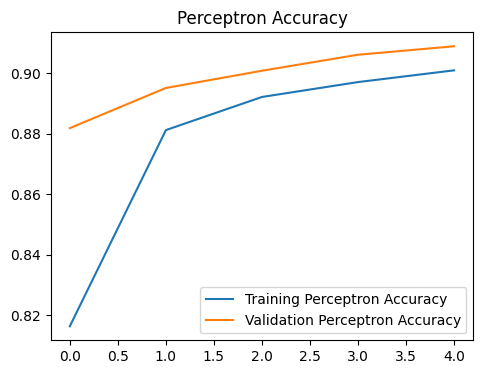

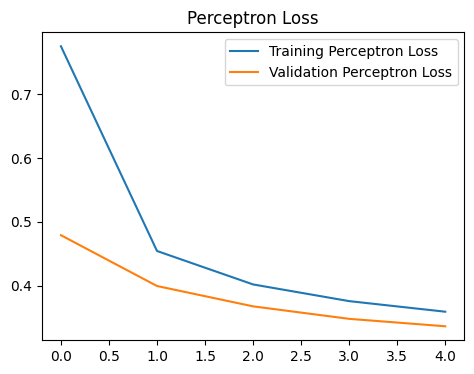

In [60]:
plot_training(history,'Perceptron')

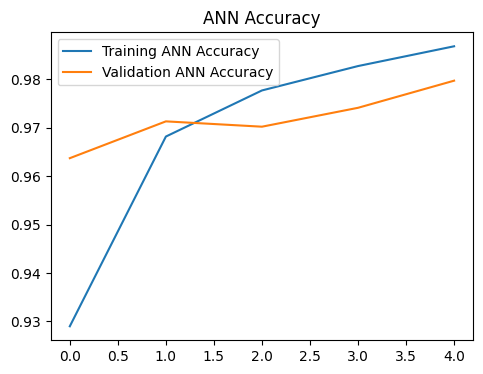

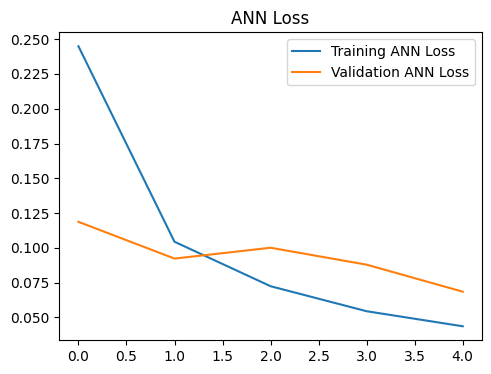

In [59]:
plot_training(history_ann,'ANN')

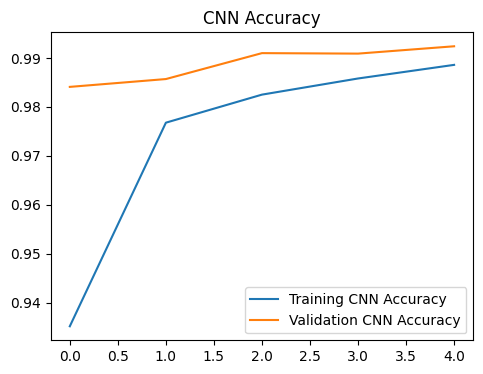

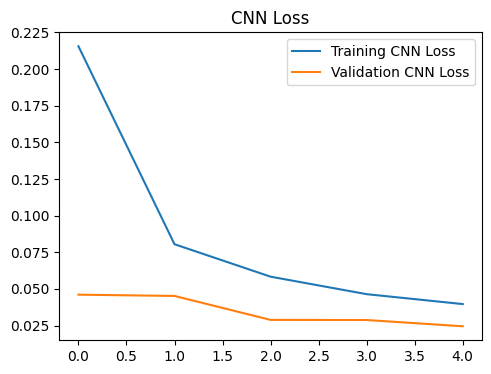

In [61]:
plot_training(history_cnn,'CNN')

### Side-by-side comparison of model predictions

In [63]:
percep_predictions = Perceptron.predict(X_test_img)
ann_predictions = ANN.predict(X_test_img)
cnn_predictions = cnn.predict(X_test_cnn)

# Convert one-hot encoded predictions back to class labels
percep_predicted_labels = np.argmax(percep_predictions, axis=1)
ann_predicted_labels = np.argmax(ann_predictions, axis=1)
cnn_predicted_labels = np.argmax(cnn_predictions, axis=1)

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'True Label': y_test,
    'Perceptron Prediction': percep_predicted_labels,
    'ANN Prediction': ann_predicted_labels,
    'CNN Prediction': cnn_predicted_labels
})

print("Sample of True Labels vs. Model Predictions:")
display(comparison_df.head(20))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Sample of True Labels vs. Model Predictions:


,True Label,Perceptron Prediction,ANN Prediction,CNN Prediction
0,7,7,7,7
1,2,2,2,2
2,1,1,1,1
3,0,0,0,0
4,4,4,4,4
5,1,1,1,1
6,4,4,4,4
7,9,9,9,9
8,5,6,5,5
9,9,9,9,9


### Visualizing Model Predictions

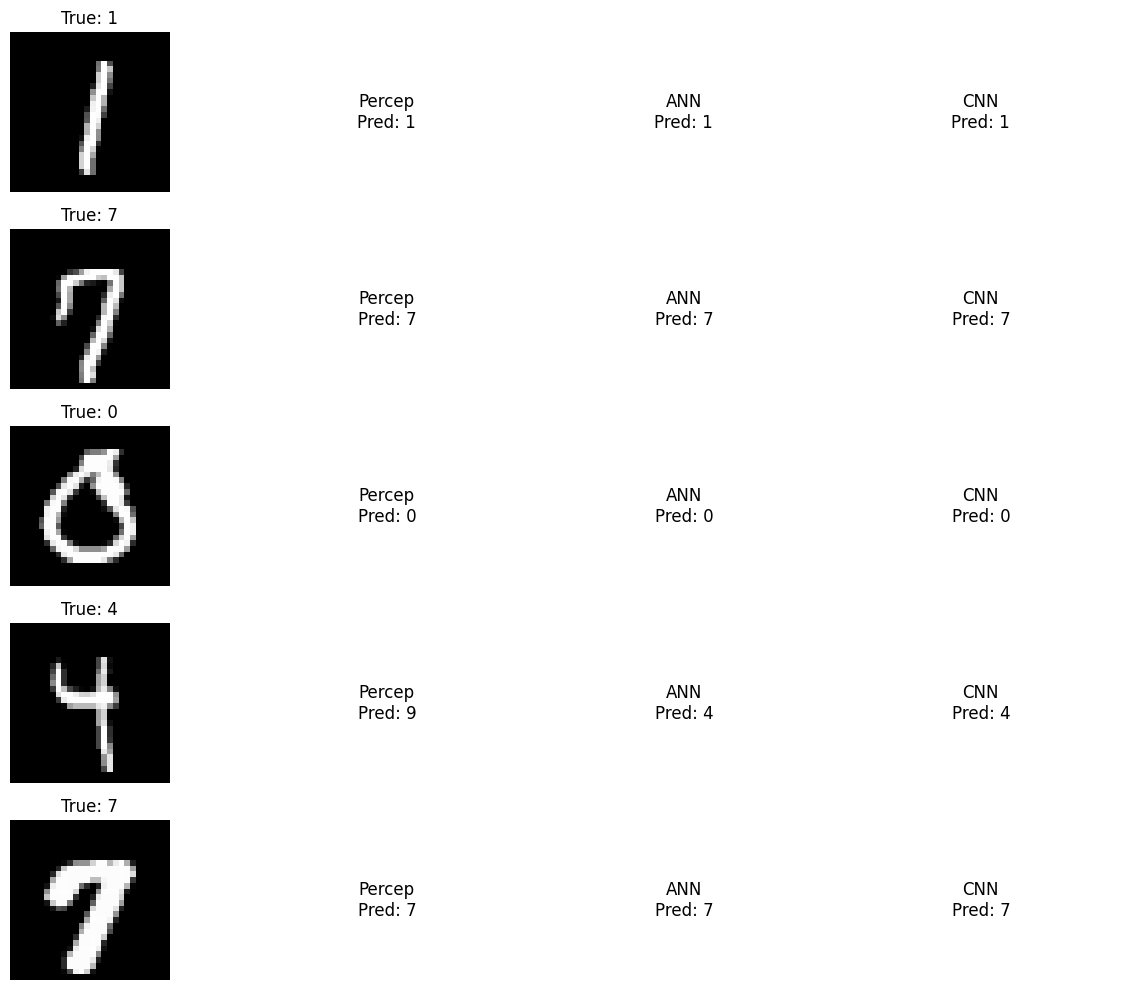

In [67]:
num_samples = 5 # Number of samples to display

plt.figure(figsize=(15, 10))
for i in range(num_samples):
    # Get a random index from the test set
    idx = np.random.randint(0, len(X_test_img))

    # Display the image
    plt.subplot(num_samples, 5, i * 5 + 1)
    plt.imshow(X_test_img[idx], cmap='gray')
    plt.title(f"True: {y_test.iloc[idx]}")
    plt.axis('off')

    # Display Perceptron prediction
    plt.subplot(num_samples, 5, i * 5 + 2)
    plt.text(0.5, 0.5, f"Percep\nPred: {percep_predicted_labels[idx]}", fontsize=12, ha='center', va='center')
    plt.axis('off')

    # Display ANN prediction
    plt.subplot(num_samples, 5, i * 5 + 3)
    plt.text(0.5, 0.5, f"ANN\nPred: {ann_predicted_labels[idx]}", fontsize=12, ha='center', va='center')
    plt.axis('off')

    # Display CNN prediction
    plt.subplot(num_samples, 5, i * 5 + 4)
    plt.text(0.5, 0.5, f"CNN\nPred: {cnn_predicted_labels[idx]}", fontsize=12, ha='center', va='center')
    plt.axis('off')

plt.tight_layout()
plt.show()

### Final Test Accuracy Comparison

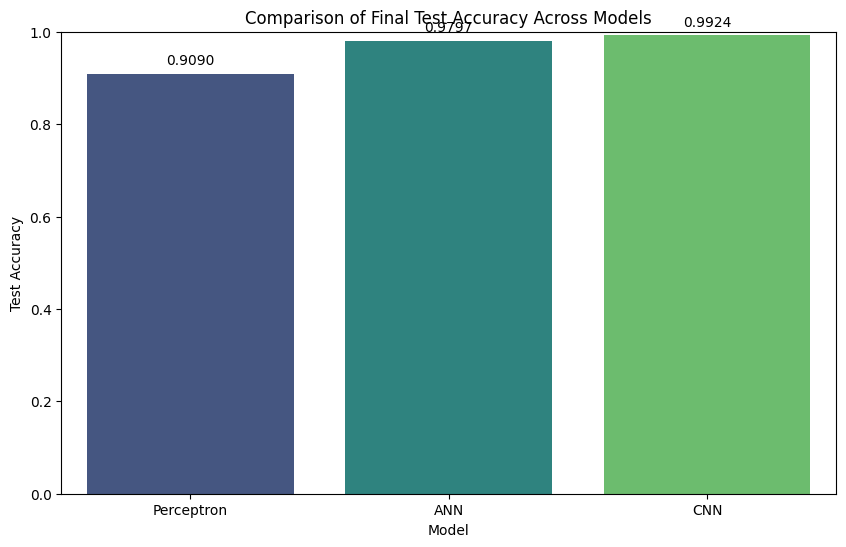

In [77]:
# Create a DataFrame for test accuracies
model_accuracies = pd.DataFrame({
    'Model': ['Perceptron', 'ANN', 'CNN'],
    'Test Accuracy': [val_acc_percep, val_acc_ann, val_acc_cnn]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Test Accuracy', data=model_accuracies, palette='viridis')
plt.title('Comparison of Final Test Accuracy Across Models')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1

# Add accuracy values on top of the bars
for index, row in model_accuracies.iterrows():
    plt.text(index, row['Test Accuracy'] + 0.02, f"{row['Test Accuracy']:.4f}", color='black', ha="center")

plt.show()

In [70]:
print("Final Test Accuracies:")
display(model_accuracies)

Final Test Accuracies:


,Model,Test Accuracy
0,Perceptron,0.9090
1,ANN,0.9797
2,CNN,0.9924
